# Structured output

means returning information in a predefined machine-readable format rather than free-form text.

# Common formats include:

{
  "name": "Alice",
  "age": 30,
  "city": "London"
}

# Benefits:

Easier for software to parse.

Consistent field names and types.

Reduces ambiguity.

Useful for APIs, automation, and data extraction.

# Why is normal text called unstructured output?

Because the information is not organized into predefined fields and there is no fixed format.

# For example:

John is 25 years old and lives in Delhi.

# s humans, we can easily understand:

Name = John,
Age = 25,
City = Delhi

But for a computer:

❌ It doesn't know exactly where the name starts and ends.

❌ It doesn't know which number is age.

❌ If the sentence changes, parsing becomes difficult.

# Why is JSON called structured output?

Because the information is organized into fixed fields.

{
  "name": "John",
  "age": 25,
  "city": "Delhi"
}



# When the model returns data in a predefined format (JSON, XML, YAML, etc.), it is called structured output.

# Why do we need structured output?

1. Store Data in Database

2. Call APIs
3. Build Reliable Applications
4. Agent and Tool Calling

# Ways to get structured output ?

1. Prompting (Simplest)
2. Few-Shot Prompting
3. Structured Output / Schema Enforcement
4. Pydantic (Most Popular in Python)
5. Function Calling / Tool Calling
6. Output Parsers
* parser.parse(response)

# How do we get structured output with structured output APIs?


You define a schema:

class Person:
    name: str
    age: int

The model is forced to return:

{
  "name": "John",
  "age": 25
}

and not:

{
  "name": "John",
  "age": "twenty five"
}

because age must be an integer.

# TypeDict

TypedDict is a way to tell Python exactly which keys a dictionary should contain and what type each value should be.

# Normal dict
person = {
    "name": "John",
    "age": 25
}

Python only knows this is a dict.

# TypedDict

from typing import TypedDict

class Person(TypedDict):
    name: str

    age: int

Now create data:

person: Person = {
    "name": "John",
    "age": 25
}

Python understands:

* name must be a str
* age must be an int

# Why use TypedDict?

* Without TypedDict:

person = {
    "name": "John",
    "age": "twenty five"  # mistake
}

Python won't complain immediately.

* With TypedDict:

person: Person = {
    "name": "John",
    "age": "twenty five"
}

Type checkers (like mypy, Pyright, VS Code) can warn:

Expected int, got str

# Easy Memory Trick
* dict = "A bag of key-value pairs"
* TypedDict = "A dictionary with a fixed schema"

# Why we need these typedict ?

# 1. Problem with normal dict
person = {
    "name": "John",
    "age": 25
}

Python allows this too:

person = {
    "name": 123,
    "age": "twenty five"
}

So issues are:

No fixed structure

No type safety

Easy to make mistakes

# 2. What TypedDict fixes
from typing import TypedDict

class Person(TypedDict):

    name: str
    
    age: int

Now rules are clear:

name must be string

age must be int

keys are fixed

# We need TypedDict because a normal Python dict does not enforce any structure or data types, which can easily lead to mistakes in large applications. For example, Python will not stop you from putting a string in place of an integer or from using incorrect keys in a dictionary. TypedDict solves this problem by allowing us to define a fixed structure for the dictionary, specifying exactly which keys are allowed and what type of values they should have. This helps catch errors early using type checkers, improves code readability, and makes it easier for developers to understand what data is expected. It is especially useful in APIs, backend systems, and LLM structured outputs where consistent data format is very important.

# TypedDict does NOT validate data at runtime.

# If you want runtime validation

Use Pydantic instead:

from pydantic import BaseModel

class Person(BaseModel):

    name: str
    
    age: int

Now this WILL fail at runtime:

Person(name="John", age="twenty five")

❌ Raises validation error

# Simple difference
* TypedDict → checks only during coding time (static)
* Pydantic → checks during execution (runtime)

👉 TypedDict does not validate data at runtime; it only provides static type hints for tools and developers to catch errors before execution.

# Code


In [ ]:
from langchain_openai import OpenAI
from dotenv import load_env
from typing import TypeDict

load_dotenv()

model = ChatOpenAI()

# schema

class Review(TypeDict):

  place:str
  rating:int
model = model.with_structured_output(Review)

result = model.invoke("What is the capital of France?")
print(result)
print(type['place'])
print(type['rating'])

# Annotated TypedDict
TypedDict ke fields ke saath extra metadata / rules add karna.

* Ye bhi mainly static typing + extra info ke liye hota hai, runtime validation nahi karta (unless extra library use karo).




# Code


In [ ]:
from typing import TypedDict, Annotated

class Person(TypedDict):
    name: Annotated[str, "user full name"]
    age: Annotated[int, "user age in years"]

# Iska meaning kya hai?

str, int → actual type

"user full name" → extra info (metadata)

# Literal TypedDict

TypedDict ke andar kisi field ko fixed allowed values (Literal) tak restrict karna.



# Pydantic

ek Python library hai jo data validation + structured data handling ke kaam aati hai.

* Ye TypedDict se next level hai kyunki ye runtime pe bhi data check karta hai.

# 1. Basic idea
from pydantic import BaseModel

class Person(BaseModel):

    name: str

    age: int
2. Now it validates at runtime

Person(name="John", age=25)   # ✅ correct

But:

Person(name="John", age="twenty five")   # ❌ error

👉 Ye run hote hi error throw karega

# Code



In [1]:
from pydantic import BaseModel

class Student(BaseModel):
  name:str
  age:int

new_student = {'name':'yash','age':21}

student= Student(**new_student)

print(student.name)
print(student.age)

yash
21


# Optional Field
wo field zaroori nahi hai, ho bhi sakti hai aur nahi bhi.



# Field function

field() function mainly Pydantic me use hota hai to define:

👉 extra rules, validation, metadata, and default behavior for a field.

#  Field() kya karta hai?
from pydantic import BaseModel, Field

class Person(BaseModel):

    name: str = Field(..., description="User full name")

    age: int = Field(..., gt=0, lt=100)



# When to use What ?

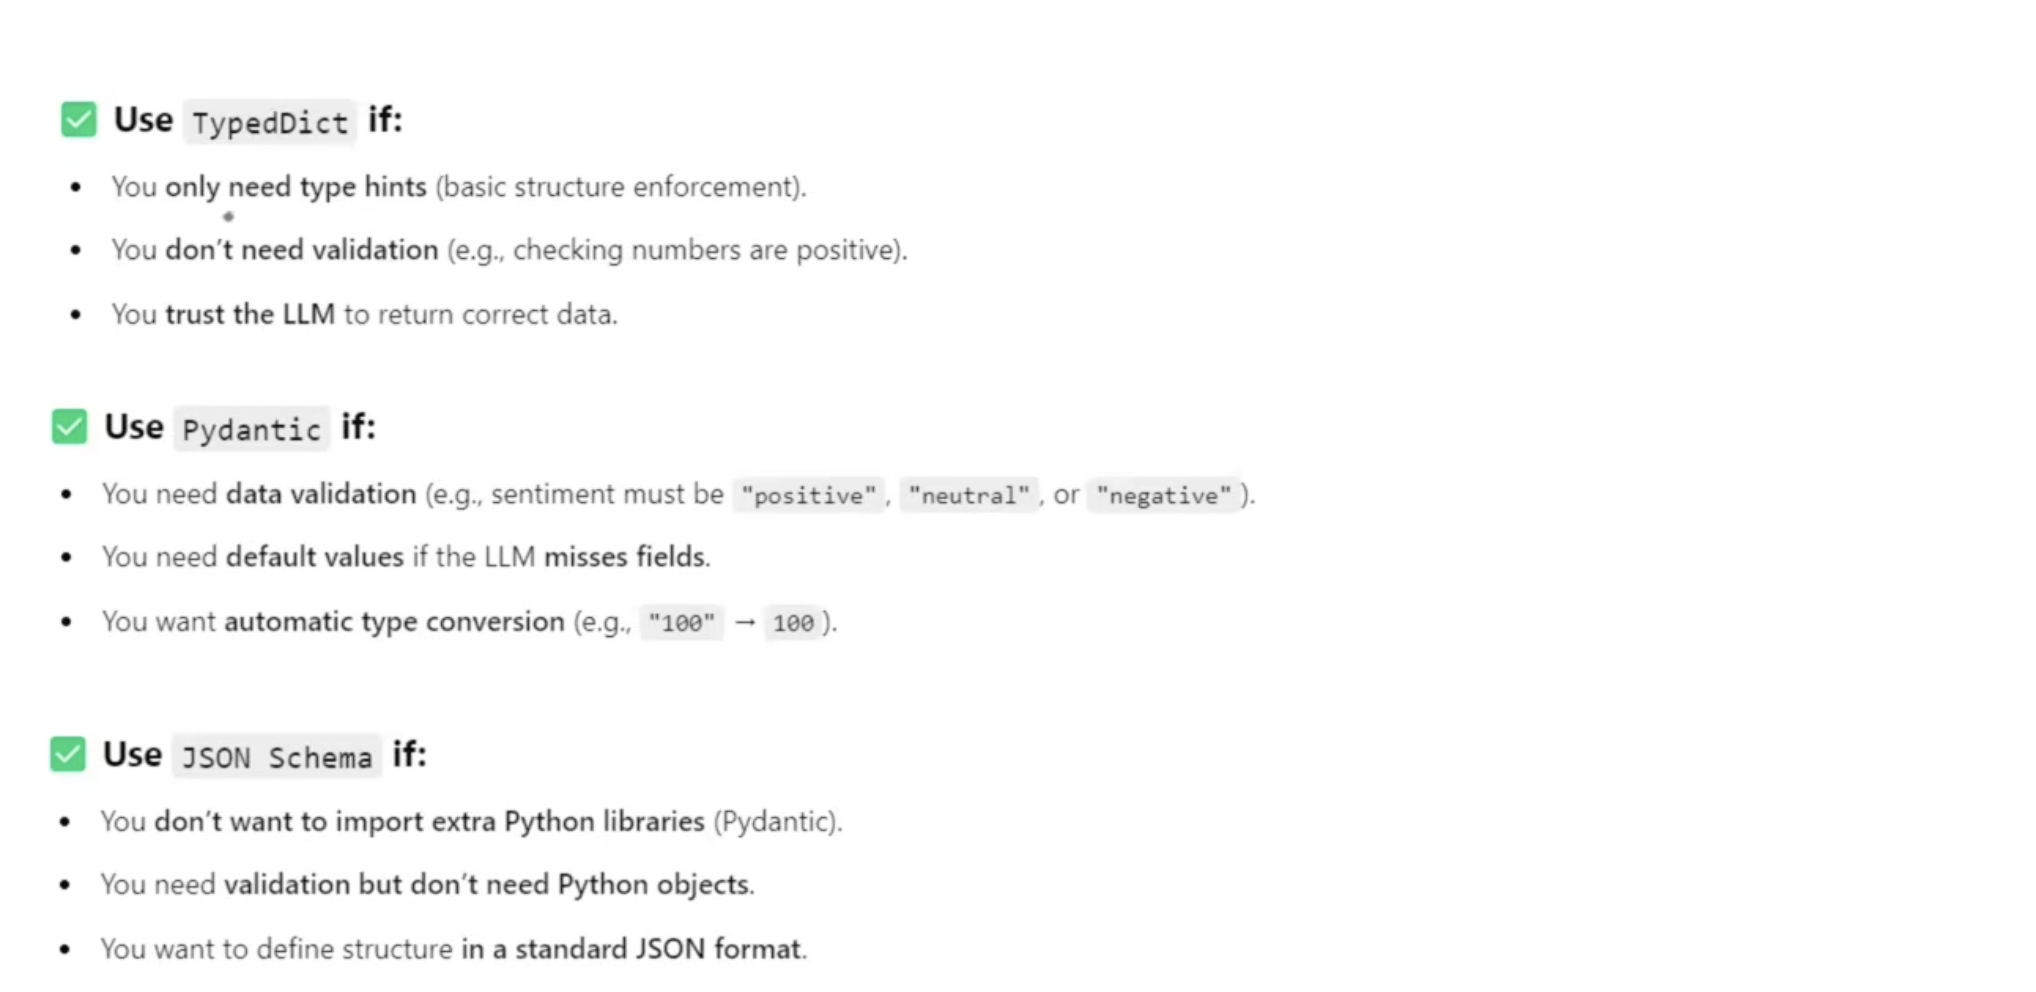


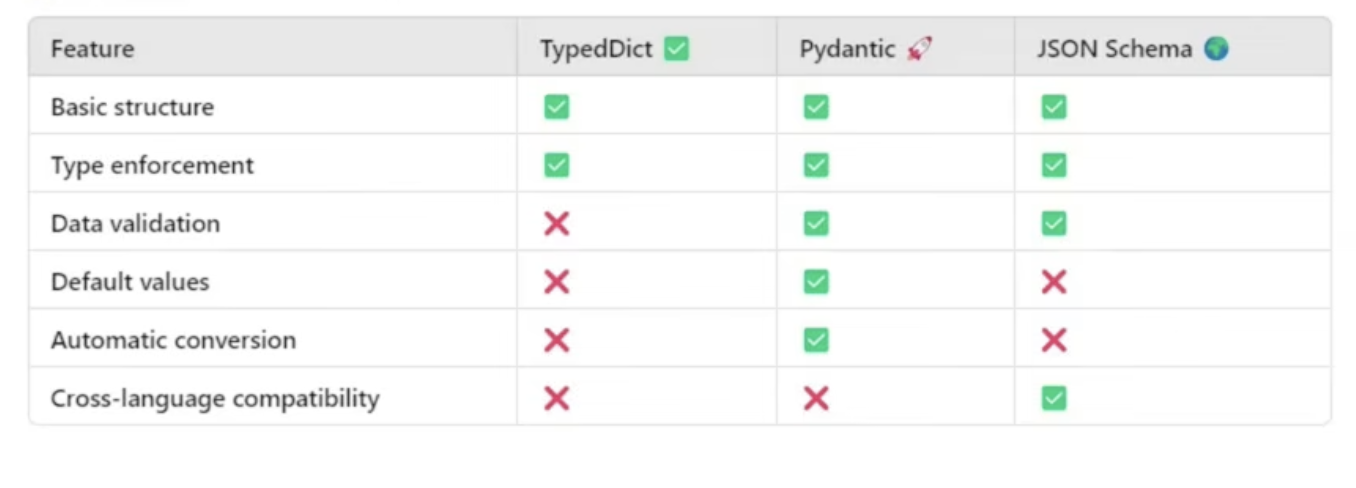